# Example Sheet 3 — Python solutions

## Question 3: Fitting the reduced model to data

We fit
$$
\dot p
=
r_{\max}\frac{a}{K_d+a}
-
\gamma_p p
$$
simultaneously to all experiments in `examples_3_data.csv`, with
$p(0)=0$ in every experiment.

### (a) Load and plot the data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

data = pd.read_csv("examples_3_data.csv")
data.head()

,experiment,time,a,p_meas
0,E1,0.0,0.03,0.000000
1,E1,0.5,0.03,0.132768
2,E1,1.0,0.03,0.213415
3,E1,1.5,0.03,0.137267
4,E1,2.0,0.03,0.306219


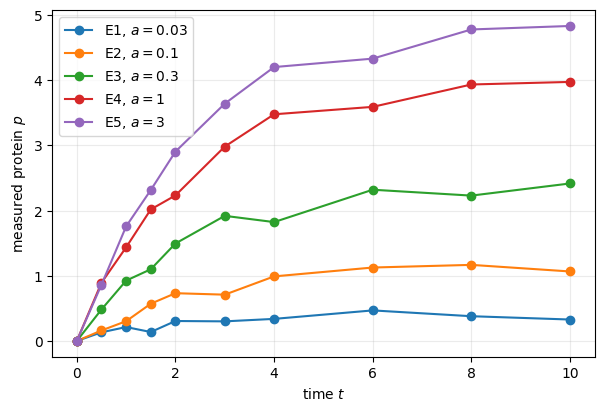

In [2]:
plt.figure(figsize=(7, 4.5))

for exp, group in data.groupby("experiment"):
    a = group["a"].iloc[0]
    plt.plot(
        group["time"],
        group["p_meas"],
        "o-",
        label=fr"{exp}, $a={a:g}$"
    )

plt.xlabel("time $t$")
plt.ylabel("measured protein $p$")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

### (b) Analytical solution

For constant $a$,
$$
p^\star(a)=\frac{r_{\max}}{\gamma_p}\frac{a}{K_d+a},
$$
and
$$
p(t)
=
p^\star(a)
+
\left[p_0-p^\star(a)\right]e^{-\gamma_p t}.
$$

In [3]:
def protein_model(t, a, p0, rmax, Kd, gamma_p):
    p_star = (rmax / gamma_p) * a / (Kd + a)
    return p_star + (p0 - p_star) * np.exp(-gamma_p * t)

### (c) Simultaneous nonlinear least-squares fit

In [4]:
def residuals(theta, data):
    rmax, Kd, gamma_p = theta

    t = data["time"].to_numpy()
    a = data["a"].to_numpy()
    y = data["p_meas"].to_numpy()

    prediction = protein_model(
        t, a, 0.0, rmax, Kd, gamma_p
    )

    return prediction - y

theta0 = np.array([1.0, 0.5, 0.5])

fit = least_squares(
    residuals,
    theta0,
    args=(data,),
    bounds=(1e-8, np.inf),
)

rmax_fit, Kd_fit, gamma_fit = fit.x

print(f"r_max   = {rmax_fit:.4f}")
print(f"K_d     = {Kd_fit:.4f}")
print(f"gamma_p = {gamma_fit:.4f}")

r_max   = 2.4694
K_d     = 0.3819
gamma_p = 0.4495


### (d) Fitted trajectories

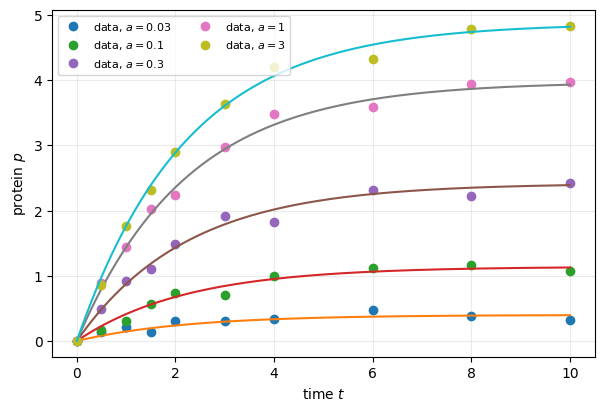

In [5]:
plt.figure(figsize=(7, 4.5))

for exp, group in data.groupby("experiment"):
    a = group["a"].iloc[0]

    plt.plot(
        group["time"],
        group["p_meas"],
        "o",
        label=fr"data, $a={a:g}$"
    )

    t_smooth = np.linspace(
        group["time"].min(),
        group["time"].max(),
        300
    )

    p_fit = protein_model(
        t_smooth,
        a,
        0.0,
        rmax_fit,
        Kd_fit,
        gamma_fit,
    )

    plt.plot(t_smooth, p_fit)

plt.xlabel("time $t$")
plt.ylabel("protein $p$")
plt.legend(ncol=2, fontsize=8)
plt.grid(True, alpha=0.25)
plt.show()

### (e) Fitted steady-state dose-response curve

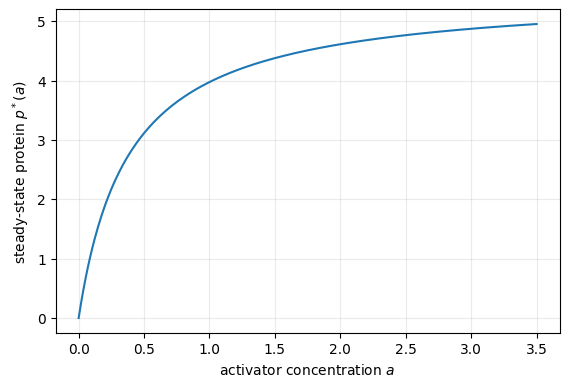

K_d = 0.3819
Maximum steady-state protein r_max/gamma_p = 5.4936


In [6]:
a_grid = np.linspace(0.0, 3.5, 400)

p_star = (
    rmax_fit / gamma_fit
    * a_grid / (Kd_fit + a_grid)
)

plt.figure(figsize=(6.5, 4.2))
plt.plot(a_grid, p_star)
plt.xlabel("activator concentration $a$")
plt.ylabel("steady-state protein $p^*(a)$")
plt.grid(True, alpha=0.25)
plt.show()

print(f"K_d = {Kd_fit:.4f}")
print(
    "Maximum steady-state protein r_max/gamma_p = "
    f"{rmax_fit/gamma_fit:.4f}"
)

$K_d$ is the activator concentration at which the steady-state response
reaches half of its maximum. The ratio $r_{\max}/\gamma_p$ is the maximum
steady-state protein concentration predicted by the reduced model.

### (f) Why use several activator concentrations?

A single trajectory mainly identifies a relaxation rate and one
steady-state level. Measurements over several values of $a$ reveal the
shape and saturation of the dose-response curve, which provides
information about $K_d$ separately from the maximum response.